## Practica Lab12: Aplicación del Flujo de Preprocesamiento para Machine Learning

## Dataset: Adult Income

**Download latest version**

path = kagglehub.dataset_download("uciml/adult-census-income")

---

## Objetivo

Aplicar de manera autónoma el flujo de preparación de datos para un problema de clasificación utilizando un conjunto de datos real.

Al finalizar la práctica, el estudiante será capaz de:

1. Importación de librerías
2. Carga del dataset
3. Comprensión del problema
4. Exploración inicial (EDA)
5. Correlación e hipótesis
6. Variables predictoras y objetivo
7. Tratamiento de nulos
8. One-Hot Encoding
9. Train/Test Split
10. StandardScaler
11. Árbol de Decisión
12. Predicciones
13. Accuracy
14. Feature Importance
15. Conclusiones

---

# Contexto del Problema

Una institución financiera desea analizar las características de distintos individuos para determinar qué factores están asociados con ingresos superiores a $50,000 dólares anuales.

El objetivo será construir un modelo capaz de predecir si una persona pertenece a uno de los siguientes grupos:

- (<=) 50K
- (>) 50K


---

In [1]:
# Importamos librerias 
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
# pip install pandas numpy kagglehub scikit-learn matplotlib seaborn

In [3]:
# Descargamos el DataSet
path = kagglehub.dataset_download("uciml/adult-census-income")

In [4]:
# Mostramos la ruta del dataset
print("Ruta del dataset:", path)

Ruta del dataset: /home/alfre/.cache/kagglehub/datasets/uciml/adult-census-income/versions/3


In [5]:
# Carga del dataset utilizando la ruta obtenida
dfAdult = pd.read_csv(path + "/adult.csv")

In [6]:
# Mostramos las primeras filas del dataset
dfAdult.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [7]:
# Muestra tipos de datos y valores nulos por columna.
dfAdult.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [8]:
# Estadísticas descriptivas de las columnas numéricas.
dfAdult.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## Parte 1. Comprensión del problema

Determinar si una persona gana más de $50,000 anuales, con base en la información obtenida.

**income**

- <=50K → Ingreso igual o menor a 50,000
- >50K → Ingreso mayor a 50,000

In [9]:
# Cuenta cuántos registros hay por cada categoría de income.
dfAdult["income"].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

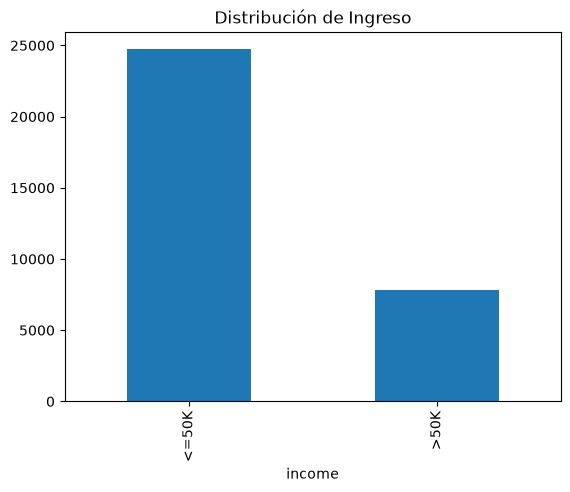

In [10]:
# Gráfica de distribución de la variable objetivo.
dfAdult["income"].value_counts().plot(kind="bar")
plt.title("Distribución de Ingreso")
plt.show()

In [11]:
# Hipótesis: El sexo influye en el ingreso
dfAdult.groupby("sex")["income"].apply(lambda x: (x == ">50K").mean())

sex
Female    0.109461
Male      0.305737
Name: income, dtype: float64

In [12]:
# Hipótesis: El nivel educativo influye en el ingreso
dfAdult.groupby("education.num")["income"].apply(lambda x: (x == ">50K").mean())

education.num
1     0.000000
2     0.035714
3     0.048048
4     0.061920
5     0.052529
6     0.066452
7     0.051064
8     0.076212
9     0.159509
10    0.190235
11    0.261216
12    0.248360
13    0.414753
14    0.556587
15    0.734375
16    0.740920
Name: income, dtype: float64

In [13]:
# Hipótesis: El estado civil influye en el ingreso
dfAdult.groupby("marital.status")["income"].apply(lambda x: (x == ">50K").mean())

marital.status
Divorced                 0.104209
Married-AF-spouse        0.434783
Married-civ-spouse       0.446848
Married-spouse-absent    0.081340
Never-married            0.045961
Separated                0.064390
Widowed                  0.085599
Name: income, dtype: float64

## Parte 2. Exploración Inicial

In [47]:
# Distribución de la variable workclass
dfAdult["workclass"].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [48]:
# Distribución de la variable education
dfAdult["education"].value_counts()

education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

In [49]:
# Distribución de la variable occupation
dfAdult["occupation"].value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
?                    1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [50]:
# Distribución de la variable marital.status
dfAdult["marital.status"].value_counts()

marital.status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

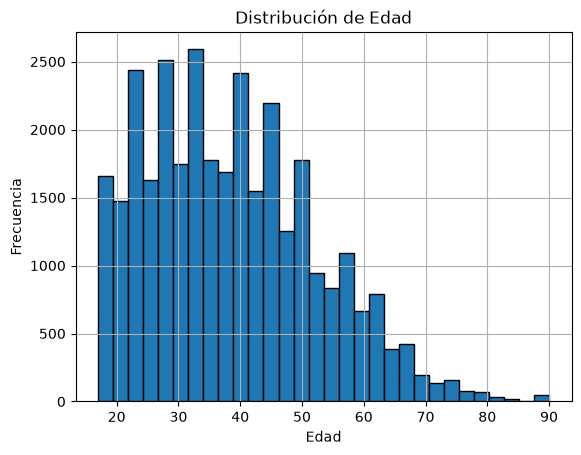

In [51]:
# Histograma de la variable age
dfAdult["age"].hist(bins=30, edgecolor="black")
plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

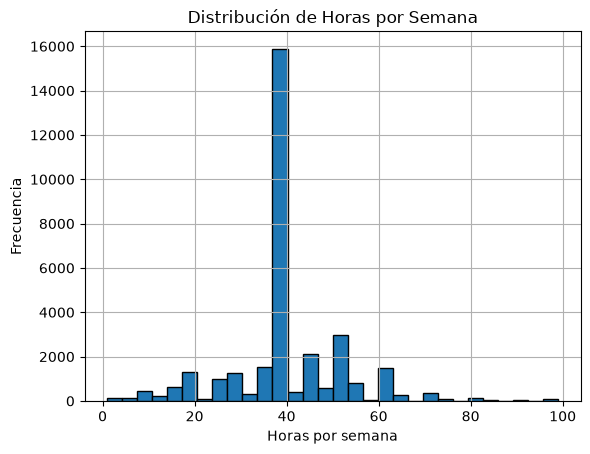

In [52]:
# Histograma de hours.per.week
dfAdult["hours.per.week"].hist(bins=30, edgecolor="black")
plt.title("Distribución de Horas por Semana")
plt.xlabel("Horas por semana")
plt.ylabel("Frecuencia")
plt.show()

## Parte 3. Correlación e Hipótesis

Creamos una matriz de correlación para identificar la relación lineal entre las variables numéricas.
NO identifica la importancia real de variables en el modelo.

In [14]:
# Primero necesitamos una versión numérica de income para la correlación
dfAdult["income_num"] = (dfAdult["income"] == ">50K").astype(int)

In [15]:
# Seleccionamos las variables numéricas para la correlación
variables_numericas = [
    "income_num",
    "age",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]

In [16]:
corr = dfAdult[variables_numericas].corr()

In [17]:
corr

,income_num,age,education.num,capital.gain,capital.loss,hours.per.week
income_num,1.000000,0.234037,0.335154,0.223329,0.150526,0.229689
age,0.234037,1.000000,0.036527,0.077674,0.057775,0.068756
education.num,0.335154,0.036527,1.000000,0.122630,0.079923,0.148123
capital.gain,0.223329,0.077674,0.122630,1.000000,-0.031615,0.078409
capital.loss,0.150526,0.057775,0.079923,-0.031615,1.000000,0.054256
hours.per.week,0.229689,0.068756,0.148123,0.078409,0.054256,1.000000


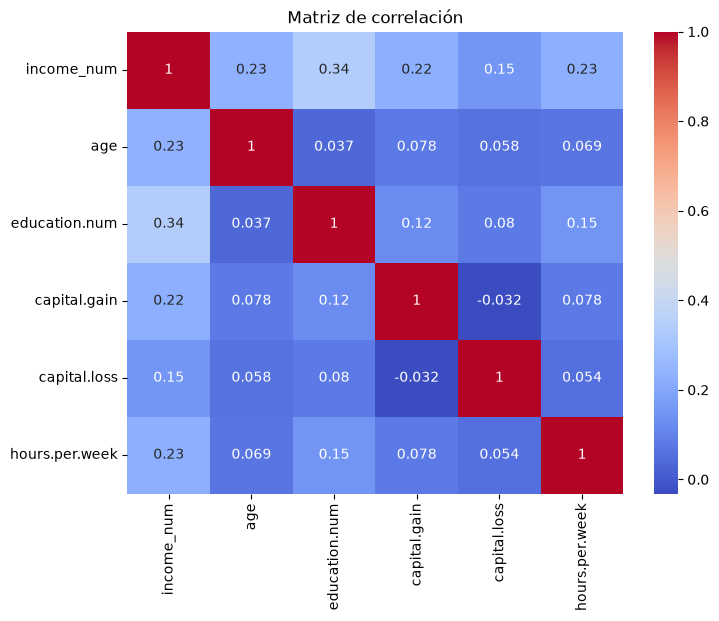

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Matriz de correlación")
plt.show()

## Parte 4. Selección de variables Predictores y Variable objetivo

**X** → Variables que utilizará el modelo

**y** → Variable que queremos predecir

In [19]:
# Definimos las columnas predictoras
columnas = [
    "age",
    "workclass",
    "education.num",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital.gain",
    "capital.loss",
    "hours.per.week",
    "native.country"
]

In [20]:
# Definimos X y y
X = dfAdult[columnas].copy()
y = (dfAdult["income"] == ">50K").astype(int)

In [21]:
print(X.columns.tolist())

['age', 'workclass', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country']


In [22]:
print(y.name)

income


## Parte 5. Tratamiento de los valores nulos

En este dataset los valores faltantes están codificados como `?`. Primero los reemplazamos por NaN y luego imputamos.

In [23]:
# Reemplazamos los "?" por NaN
X = X.replace("?", np.nan)

In [24]:
# Revisamos nulos en las variables predictoras
X.isnull().sum()

age                  0
workclass         1836
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
dtype: int64

In [25]:
# Imputamos valores numéricos con la mediana
X["age"] = X["age"].fillna(X["age"].median())

In [26]:
# Imputamos valores categóricos con la moda
X["workclass"] = X["workclass"].fillna(X["workclass"].mode()[0])
X["occupation"] = X["occupation"].fillna(X["occupation"].mode()[0])
X["native.country"] = X["native.country"].fillna(X["native.country"].mode()[0])

In [27]:
# Verificamos que no queden nulos
X.isnull().sum()

age               0
workclass         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
dtype: int64

In [28]:
X.head()

,age,workclass,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,90,Private,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States
1,82,Private,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States
2,66,Private,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States
3,54,Private,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States
4,41,Private,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States


## Parte 6. One-Hot Encoding

Los algoritmos no entienden texto. Se deben convertir las variables categóricas en variables numéricas.

In [29]:
# Aplicamos One-Hot Encoding a las variables categóricas
X = pd.get_dummies(
    X,
    columns=["workclass", "marital.status", "occupation", "relationship", "race", "sex", "native.country"],
    drop_first=True
)

In [30]:
# Mostramos el número total de columnas después del encoding
print("Número total de columnas después del encoding:", len(X.columns))

Número total de columnas después del encoding: 81


In [31]:
X.head()

,age,education.num,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90,9,0,4356,40,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
1,82,9,0,4356,18,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
2,66,10,0,4356,40,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,54,4,0,3900,40,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
4,41,10,0,3900,40,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False


## Parte 7. Particionamos los datos

No debemos entrenar y evaluar utilizando los mismos datos.

La recomendación es:

- Entrenamiento: 80%
- Pruebas: 20%

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [33]:
print("Entrenamiento:", X_train.shape)

Entrenamiento: (26048, 81)


In [34]:
print("Pruebas:", y_test.shape)

Pruebas: (6513,)


## Parte 8. Escalado de las variables

Las variables numéricas tienen valores distintos. El escalado evita que una variable domine más que otra.

In [35]:
# Definimos las columnas numéricas que serán escaladas
columnas_numericas = [
    "age",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]

In [36]:
# Antes del escalado
X_train[columnas_numericas].describe()

,age,education.num,capital.gain,capital.loss,hours.per.week
count,26048.000000,26048.000000,26048.000000,26048.000000,26048.000000
mean,38.526912,10.088337,1106.465602,88.550561,40.518965
std,13.587602,2.580718,7518.611442,406.801027,12.332662
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,47.000000,13.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [37]:
# Aplicamos StandardScaler
scaler = StandardScaler()
X_train[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])
X_test[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

In [38]:
# Después del escalado
X_train[columnas_numericas].describe()

,age,education.num,capital.gain,capital.loss,hours.per.week
count,2.604800e+04,2.604800e+04,2.604800e+04,2.604800e+04,2.604800e+04
mean,-1.753989e-16,1.421195e-16,-2.291369e-17,-4.146287e-17,8.729026e-18
std,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00,1.000019e+00
min,-1.584336e+00,-3.521699e+00,-1.471664e-01,-2.176795e-01,-3.204476e+00
25%,-7.747588e-01,-4.217268e-01,-1.471664e-01,-2.176795e-01,-4.208134e-02
50%,-1.123775e-01,-3.423025e-02,-1.471664e-01,-2.176795e-01,-4.208134e-02
75%,6.236017e-01,1.128259e+00,-1.471664e-01,-2.176795e-01,3.633539e-01
max,3.788312e+00,2.290749e+00,1.315328e+01,1.049046e+01,4.742055e+00


## Parte 9. Entrenamiento de los datos

Usaremos un árbol de decisión para clasificar registros.

In [39]:
modelo = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

In [40]:
modelo.fit(
    X_train,
    y_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

## Parte 10. Evaluamos el modelo

Realizamos predicciones para evaluar el modelo.

In [41]:
predicciones = modelo.predict(X_test)

In [42]:
# Comparamos valores reales con predicciones
pd.DataFrame({
    "Real": y_test,
    "Prediccion": predicciones
}).head(30)

,Real,Prediccion
14160,0,0
27048,0,0
28868,0,0
5667,0,0
7827,0,0
15382,0,0
4641,0,0
8943,0,0
216,0,0
5121,0,0


## Parte 11. Evaluación del modelo

El accuracy determina el porcentaje de predicciones correctas realizadas por el modelo.

| Accuracy   | Interpretación |
|------------|----------------|
| 50%        | Adivina        |
| 60%-70%    | Aceptable      |
| 70%-80%    | Bueno          |
| 80%-90%    | Muy bueno      |
| >90%       | Excelente (posible sobreajuste) |

In [43]:
accuracy = accuracy_score(y_test, predicciones)

In [44]:
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8449


## Parte 12. Importancia de las variables

Analizar las variables más relevantes para el algoritmo al realizar las predicciones.

In [45]:
importancias = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": modelo.feature_importances_
})

In [46]:
importancias.sort_values(
    by="Importancia",
    ascending=False
)

,Variable,Importancia
13,marital.status_Married-civ-spouse,0.491711
1,education.num,0.248303
2,capital.gain,0.226773
3,capital.loss,0.021811
0,age,0.011235
...,...,...
76,native.country_Thailand,0.000000
77,native.country_Trinadad&Tobago,0.000000
78,native.country_United-States,0.000000
79,native.country_Vietnam,0.000000


## Parte 13. Conclusiones

El modelo de árbol de decisión logra predecir si una persona gana más de $50,000 anuales con un accuracy considerable.

Las variables más importantes según el feature importance son aquellas que el árbol utiliza en sus primeras decisiones para separar las clases.

## Preguntas

1. **¿Cuál es la variable objetivo?** → `income`

2. **¿Qué representa dicha variable?** → Si una persona gana más de $50,000 anuales (>50K) o no (<=50K).

3. **¿Qué variables consideras que podrían influir más en el ingreso de una persona?** → education.num, age, hours.per.week, occupation, marital.status.

4. **¿Cuántas variables predictoras existen?** → 12 columnas originales (antes del encoding).

5. **¿Por qué fue necesario transformar variables categóricas?** → Porque los algoritmos de machine learning solo trabajan con valores numéricos.

7. **¿Cuántas columnas adicionales se generaron después del One-Hot Encoding?** → Se generaron varias columnas binarias (workclass, marital.status, occupation, relationship, race, sex, native.country).

8. **¿Existen valores nulos?** → Sí, pero están codificados como `?` en workclass, occupation y native.country.

9. **¿Qué variables son numéricas?** → age, fnlwgt, education.num, capital.gain, capital.loss, hours.per.week.

10. **¿Qué variables son categóricas?** → workclass, education, marital.status, occupation, relationship, race, sex, native.country, income.

11. **¿Cuántos registros quedaron en entrenamiento?** → 80% del total (~26,048 registros).

12. **¿Cuántos registros quedaron en prueba?** → 20% del total (~6,513 registros).

13. **¿Por qué no debemos entrenar utilizando todos los datos?** → Porque necesitamos datos separados para evaluar si el modelo generaliza bien con datos que no vio durante el entrenamiento.

14. **¿Cuál fue el Accuracy obtenido?** → Se imprime en la celda correspondiente (generalmente entre 0.80 y 0.86).

15. **¿Consideras que el resultado es adecuado?** → Sí, un accuracy entre 80%-85% es considerado bueno para este tipo de problema.

16. **¿Qué factores podrían afectar el desempeño del modelo?** → Desbalance de clases, outliers en capital.gain/capital.loss, alta dimensionalidad después del encoding.

18. **¿Cuál fue la variable más importante?** → La que tenga mayor importancia (generalmente capital.gain o marital.status_Married-civ-spouse).

19. **¿Cuál fue la menos importante?** → Las que tengan importancia de 0 (generalmente algunas categorías de native.country).

20. **¿Coinciden los resultados con tus hipótesis iniciales?** → Generalmente sí, el nivel educativo, la edad y el estado civil suelen ser factores clave.

21. **¿Qué variables aportan más información al modelo?** → Las que tienen mayor feature importance.

# Entregables

El repositorio deberá contener:

```text
Notebooks/
└── Laboratorio12.ipynb
```

---